## Importing Library

In [2]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib
from time import sleep
import contextily as cx
import xyzservices.providers as xyz
import os
import gc

## Shape file preprocess

In [4]:
bin_folder = r"D:\dipen" # directory of all files

In [6]:
# opening river file and grid file
grid_index_shp = gpd.read_file(os.path.join(bin_folder, "south-texas-lidar-tile-index.zip")).to_crs(32614)
bnd_shp = gpd.read_file(os.path.join(bin_folder, "Matagorda area local domain.zip")).to_crs(32614)

In [53]:
## Buffer of the river
# river_buff = river_shp.to_crs(3857).buffer(200).to_crs(4326)
# river_buff_shp = gpd.GeoDataFrame({'ids':range(len(river_buff)), 
#                               'geometry': river_buff}, geometry='geometry', crs=4326)

## Plotting all shape file over base map

ConnectionError: HTTPSConnectionPool(host='tile.openstreetmap.org', port=443): Max retries exceeded with url: /8/56/106.png (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000002A935AE3380>: Failed to resolve 'tile.openstreetmap.org' ([Errno 11001] getaddrinfo failed)"))

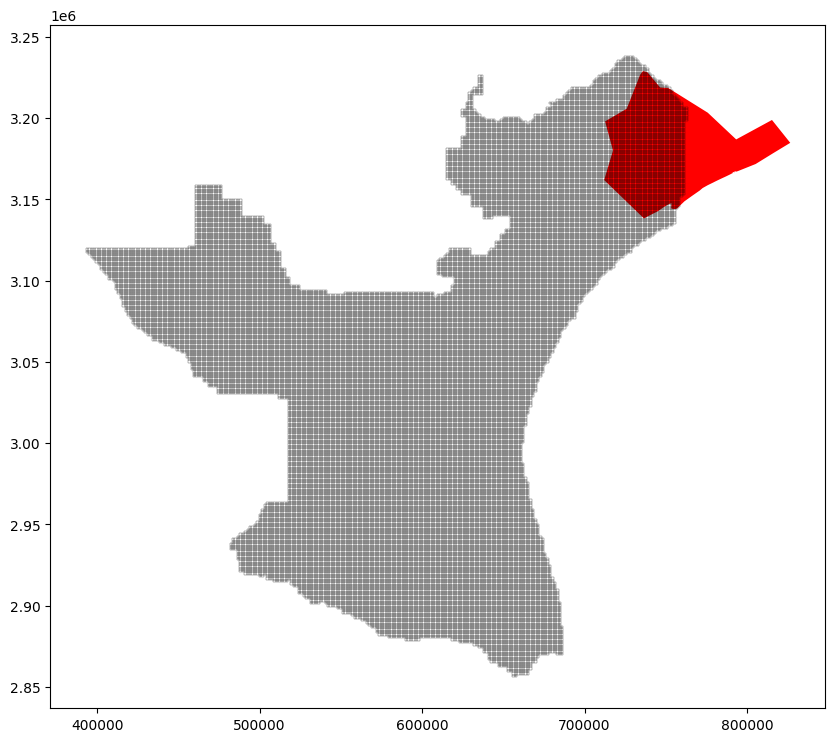

In [12]:

fig, ax = plt.subplots(figsize=(10,10))
bnd_shp.plot(ax=ax, color='r')
# river_buff.plot(ax=ax)
grid_index_shp.plot(ax=ax, fc='None', ec='k', lw=0.2)
cx.add_basemap(ax, crs=grid_index_shp.crs,
               source=xyz.OpenStreetMap.Mapnik)

## River buffer intersection with grid file

In [9]:
test_intersect = gpd.sjoin(grid_index_shp, bnd_shp, how='left', predicate='intersects')

In [11]:
river_grid_index = test_intersect[~test_intersect['index_right'].isnull()]

In [13]:
river_grid_index

,NAME,DESCRIPTIO,geometry,index_right,Id
23858,usgs18-70cm_14RQS711160,usgs18-1m_14RQS711160,"POLYGON ((711000 3162000, 712500 3162000, 7125...",0.0,0.0
23859,usgs18-70cm_14RQS711162,usgs18-1m_14RQS711162,"POLYGON ((711000 3163500, 712500 3163500, 7125...",0.0,0.0
23921,usgs18-70cm_14RQS712159,usgs18-1m_14RQS712159,"POLYGON ((712500 3160500, 714000 3160500, 7140...",0.0,0.0
23922,usgs18-70cm_14RQS712160,usgs18-1m_14RQS712160,"POLYGON ((712500 3162000, 714000 3162000, 7140...",0.0,0.0
23923,usgs18-70cm_14RQS712162,usgs18-1m_14RQS712162,"POLYGON ((712500 3163500, 714000 3163500, 7140...",0.0,0.0
...,...,...,...,...,...
26255,usgs18-70cm_14RQT760205,usgs18-1m_14RQT760205,"POLYGON ((760500 3207000, 762000 3207000, 7620...",0.0,0.0
26256,usgs18-70cm_14RQT762201,usgs18-1m_14RQT762201,"POLYGON ((762000 3202500, 763500 3202500, 7635...",0.0,0.0
26257,usgs18-70cm_14RQT762202,usgs18-1m_14RQT762202,"POLYGON ((762000 3204000, 763500 3204000, 7635...",0.0,0.0
26258,usgs18-70cm_14RQT762204,usgs18-1m_14RQT762204,"POLYGON ((762000 3205500, 763500 3205500, 7635...",0.0,0.0


## Downloading files

In [ ]:
for idx, row in river_grid_index.iterrows():
    test_index = row['DESCRIPTIO']
    download_link = r"https://tnris-data-warehouse.s3.us-east-1.amazonaws.com/LCD/collection/usgs-2018-70cm-south-texas/dem/{}.img".format(test_index)
    file_name = f"{test_index}.img"
    response = urllib.request.urlopen(download_link)
    with open(r'D:\dipen\downloaded_files\{}'.format(file_name),'wb') as output:
        output.write(response.read())
        output.close()
    del response
    gc.collect()
    print(f"{test_index} is done")
    sleep(1)

usgs18-1m_14RQS711160 is done
usgs18-1m_14RQS711162 is done
usgs18-1m_14RQS712159 is done
usgs18-1m_14RQS712160 is done
usgs18-1m_14RQS712162 is done
usgs18-1m_14RQS712163 is done
usgs18-1m_14RQS712165 is done
usgs18-1m_14RQS712166 is done
usgs18-1m_14RQS712168 is done
usgs18-1m_14RQS712192 is done
usgs18-1m_14RQS712193 is done
usgs18-1m_14RQS712195 is done
usgs18-1m_14RQS712196 is done
usgs18-1m_14RQS712198 is done
usgs18-1m_14RQS714157 is done
usgs18-1m_14RQS714159 is done
usgs18-1m_14RQS714160 is done
usgs18-1m_14RQS714162 is done
usgs18-1m_14RQS714163 is done
usgs18-1m_14RQS714165 is done
usgs18-1m_14RQS714166 is done
usgs18-1m_14RQS714168 is done
usgs18-1m_14RQS714169 is done
usgs18-1m_14RQS714171 is done
usgs18-1m_14RQS714172 is done
usgs18-1m_14RQS714186 is done
usgs18-1m_14RQS714187 is done
usgs18-1m_14RQS714189 is done
usgs18-1m_14RQS714190 is done
usgs18-1m_14RQS714192 is done
usgs18-1m_14RQS714193 is done
usgs18-1m_14RQS714195 is done
usgs18-1m_14RQS714196 is done
usgs18-1m_

## Checking if all files are correctly downloaded

In [ ]:
downloaded_file_names = os.listdir(r"D:\dipen\downloaded_files")

In [82]:
downloaded_file_id = [i.split('.')[0] for i in downloaded_file_names]

In [87]:
river_grid_index[river_grid_index['DESCRIPTIO'].isin(downloaded_file_id)]

,NAME,DESCRIPTIO,geometry,index_right,ids
11263,usgs18-70cm_14RNR585015,usgs18-1m_14RNR585015,"POLYGON ((-98.14124 27.26880, -98.12609 27.268...",16.0,16.0
11324,usgs18-70cm_14RNR586013,usgs18-1m_14RNR586013,"POLYGON ((-98.12620 27.25517, -98.11105 27.255...",16.0,16.0
11325,usgs18-70cm_14RNR586015,usgs18-1m_14RNR586015,"POLYGON ((-98.12609 27.26871, -98.11094 27.268...",16.0,16.0
11384,usgs18-70cm_14RNR588010,usgs18-1m_14RNR588010,"POLYGON ((-98.11126 27.22799, -98.09611 27.227...",16.0,16.0
11385,usgs18-70cm_14RNR588012,usgs18-1m_14RNR588012,"POLYGON ((-98.11115 27.24153, -98.09600 27.241...",16.0,16.0
...,...,...,...,...,...
26183,usgs18-70cm_14RQT748216,usgs18-1m_14RQT748216,"POLYGON ((-96.44760 29.06160, -96.43220 29.061...",7.0,7.0
26184,usgs18-70cm_14RQT748217,usgs18-1m_14RQT748217,"POLYGON ((-96.44726 29.07512, -96.43187 29.074...",6.0,6.0
26184,usgs18-70cm_14RQT748217,usgs18-1m_14RQT748217,"POLYGON ((-96.44726 29.07512, -96.43187 29.074...",7.0,7.0
26197,usgs18-70cm_14RQT750217,usgs18-1m_14RQT750217,"POLYGON ((-96.43187 29.07483, -96.41647 29.074...",7.0,7.0


In [86]:
len(downloaded_file_id)

443

In [89]:
len(river_grid_index['DESCRIPTIO'].unique())

443